#Mounting Drive


In [19]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
%pwd

'/content/drive/My Drive/YOLOv11 projects/Self Driving Car/Road Segmentation (Driveable Area Segmentation)'

In [21]:
%cd /content/drive/MyDrive/YOLOv11 projects/Self Driving Car/Road Segmentation (Driveable Area Segmentation)

/content/drive/MyDrive/YOLOv11 projects/Self Driving Car/Road Segmentation (Driveable Area Segmentation)


In [22]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 32.7/235.7 GB disk)


# Test - CLI

In [ ]:
!yolo segment predict model=yolo11n-seg.pt source='inference/people.jpg' show_labels=false show_boxes=false

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11n-seg summary (fused): 265 layers, 2,868,664 parameters, 0 gradients, 10.4 GFLOPs

image 1/1 /content/drive/MyDrive/YOLOv11 projects/Self Driving Car/Road Segmentation (Driveable Area Segmentation)/inference/people.jpg: 480x640 5 persons, 1 handbag, 1 cup, 1 chair, 1 potted plant, 85.0ms
Speed: 5.1ms preprocess, 85.0ms inference, 577.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/segment/predict3
💡 Learn more at https://docs.ultralytics.com/modes/predict


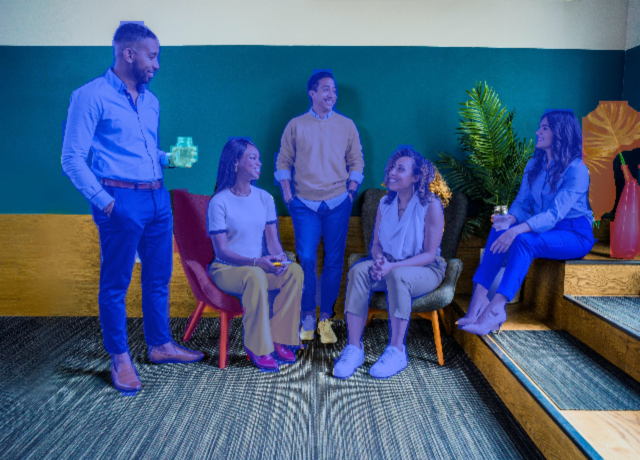

In [ ]:
import cv2
import imutils
from google.colab.patches import cv2_imshow

path="runs/segment/predict3/people.jpg"

img=cv2.imread(path)
img=imutils.resize(img,width=640)

cv2_imshow(img)


#Train

In [ ]:
!unzip data/road_surface_dataset.zip -d ./data

Görüntülenen çıkış son 5000 satıra kısaltıldı.
 extracting: ./data/train/images/00071_K2zYpFPmgy_png.rf.1e35e776b676cfab1c69d768913c2443.jpg  
 extracting: ./data/train/images/00071_K2zYpFPmgy_png.rf.703401f6552afeb8ff7fadffe1bae3d6.jpg  
 extracting: ./data/train/images/00071_K2zYpFPmgy_png.rf.b1f9b22d64940f54a237301b522c851a.jpg  
 extracting: ./data/train/images/00071_png.rf.0078e14d674802bc7a2c905b580c189c.jpg  
 extracting: ./data/train/images/00071_png.rf.5d7a765532e517e038c05323d086d27d.jpg  
 extracting: ./data/train/images/00071_png.rf.9a3dd01d7d5d57d1b136d670e56255f7.jpg  
 extracting: ./data/train/images/00072_6pluDjEi2E_png.rf.285b0b000b34bc40117dd3ad04783b13.jpg  
 extracting: ./data/train/images/00072_6pluDjEi2E_png.rf.286b4ed8db43d741765e246dc7620a69.jpg  
 extracting: ./data/train/images/00072_6pluDjEi2E_png.rf.b649ec872b654212fa52289eb16fe8a9.jpg  
 extracting: ./data/train/images/00072_png.rf.063955c2300e9ed2cd8b7ae0edd49d8a.jpg  
 extracting: ./data/train/images/0007

In [ ]:
!yolo segment train data=data/data.yaml model=yolo11l-seg.pt epochs=100 imgsz=640 workers=8 batch=8 device=0 name=yolov11_road_segmentation

100% 53.5M/53.5M [00:01<00:00, 40.9MB/s]
Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
engine/trainer: task=segment, mode=train, model=yolo11l-seg.pt, data=data/data.yaml, epochs=100, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=yolov11_road_segmentation2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_cro

In [ ]:
!yolo segment train model=runs/segment/yolov11_road_segmentation2/weights/last.pt resume=True

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
engine/trainer: task=segment, mode=train, model=runs/segment/yolov11_road_segmentation2/weights/last.pt, data=data/data.yaml, epochs=100, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=yolov11_road_segmentation22, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=runs/segment/yolov11_road_segmentation2/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_fram

#Results

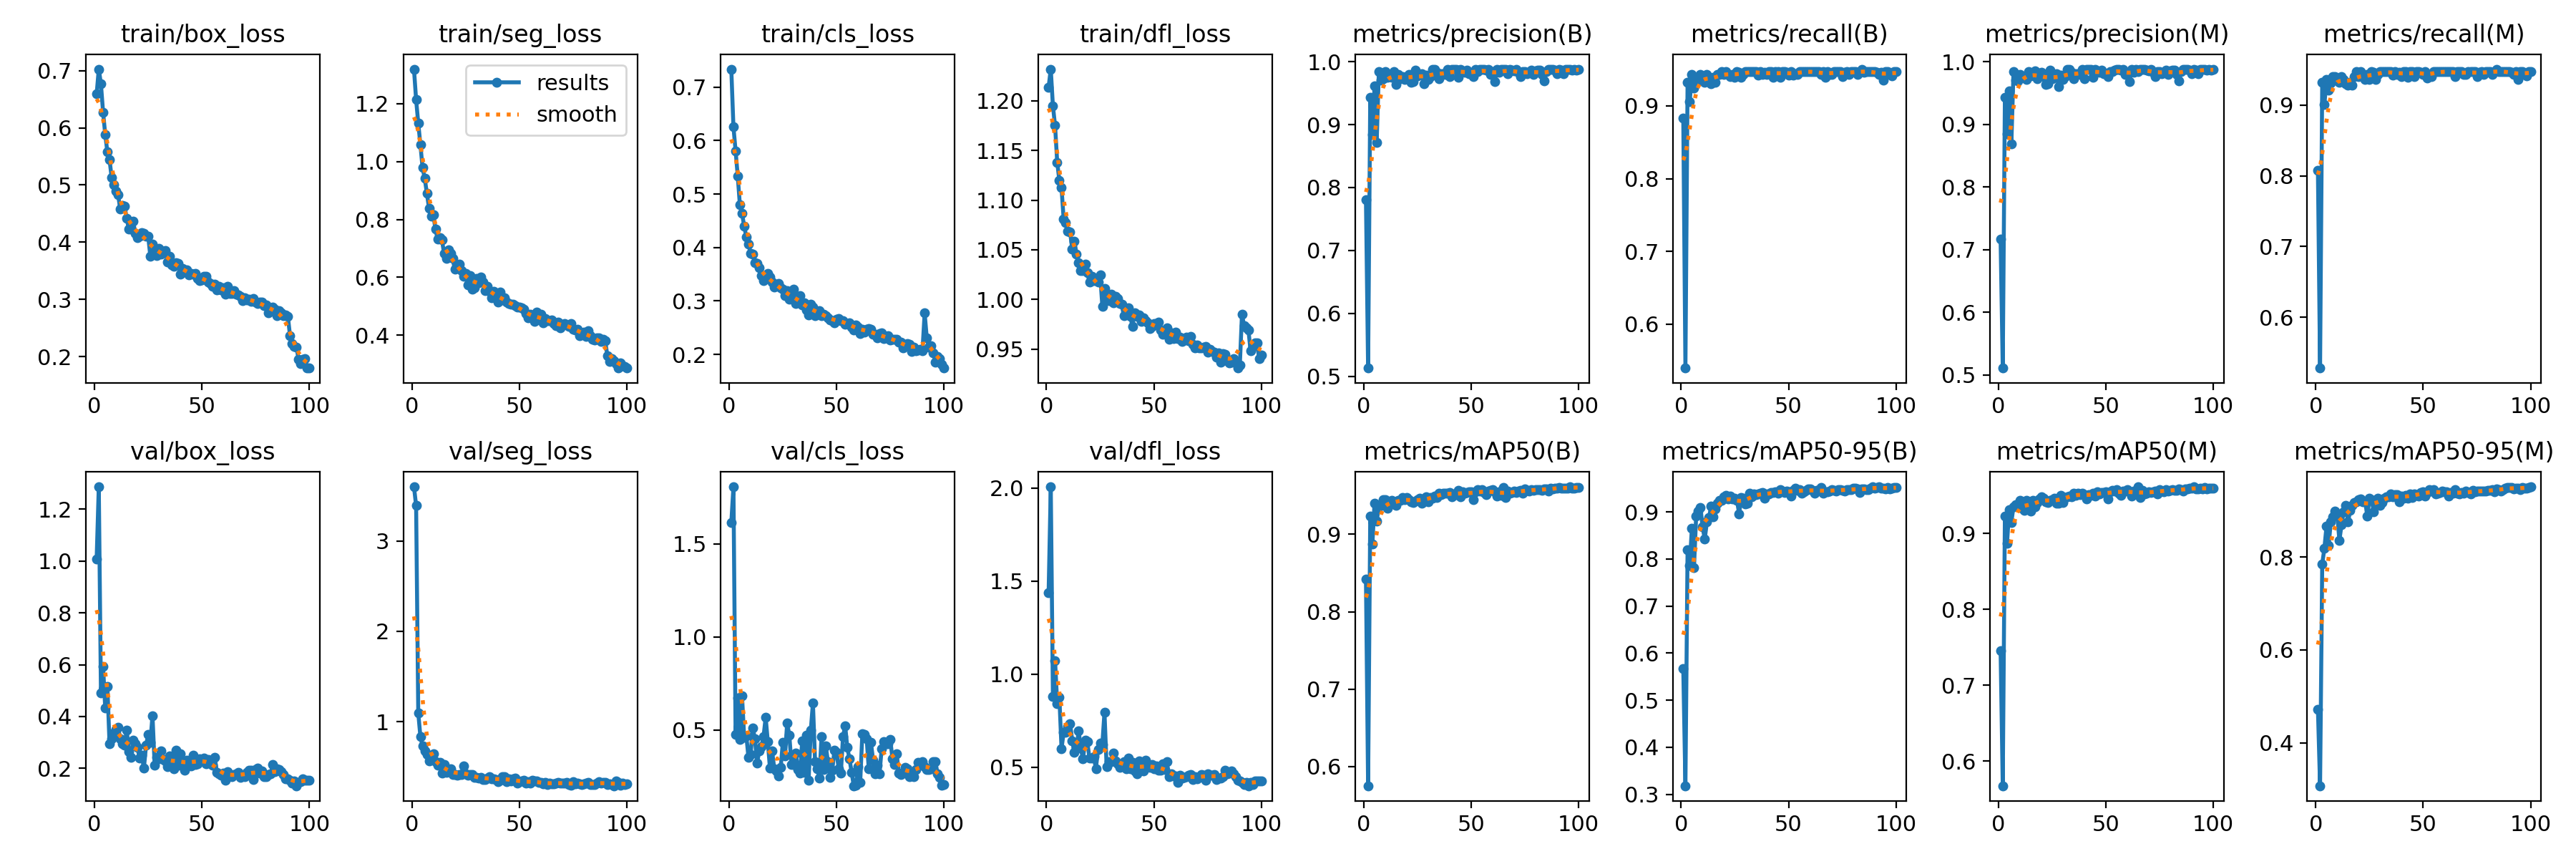

In [9]:
import cv2
from google.colab.patches import cv2_imshow

path="runs/segment/yolov11_road_segmentation2/results.png"

img=cv2.imread(path)

cv2_imshow(img)

#Prediction

In [23]:
!yolo segment predict model="runs/segment/yolov11_road_segmentation2/weights/best.pt" source='inference/road.jpg' show_labels=false show_boxes=false

Ultralytics 8.3.38 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
YOLO11l-seg summary (fused): 491 layers, 27,585,363 parameters, 0 gradients, 141.9 GFLOPs

image 1/1 /content/drive/MyDrive/YOLOv11 projects/Self Driving Car/Road Segmentation (Driveable Area Segmentation)/inference/road.jpg: 448x640 1 road, 89.3ms
Speed: 5.0ms preprocess, 89.3ms inference, 637.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/segment/predict5
💡 Learn more at https://docs.ultralytics.com/modes/predict


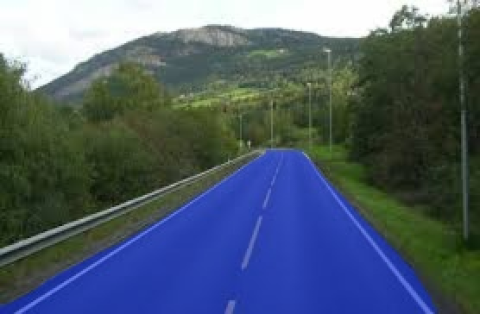

In [24]:
import cv2
import imutils
from google.colab.patches import cv2_imshow

path="runs/segment/predict5/road.jpg"
img=cv2.imread(path)

img=imutils.resize(img,width=480)

cv2_imshow(img)

#Prediction - Python İmplementation


0: 448x640 1 road, 21.9ms
masks: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
boxes: tensor([[  0.0000,  86.8177, 257.1552, 181.9690,   0.9212,   0.0000]])
clss: [          0]


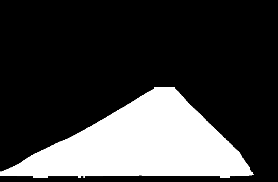

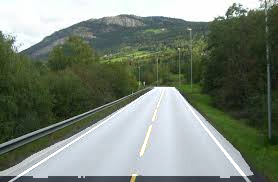

Speed: 1.8ms preprocess, 21.9ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/segment/predict8


In [28]:
import cv2
from google.colab.patches import cv2_imshow
import torch
import numpy as np
from ultralytics import YOLO

# Görüntü ve model yolları
img_path = "inference/road.jpg"
model_path = "runs/segment/yolov11_road_segmentation2/weights/best.pt"

# Görüntüyü yükle
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Görüntü bulunamadı: {img_path}")

# Modeli yükle
model = YOLO(model_path)

# Tahmin yap
results = model.predict(img.copy(), save=True, save_txt=False, stream=True)

# Sonuçları işleme
for result in results:
    masks = result.masks.data.cpu()  # CUDA tensörünü CPU'ya taşı
    print(f"masks: {masks}") #tensör döndürür.

    boxes = result.boxes.data.cpu()  # Kutuları CPU'ya taşı
    print(f"boxes: {boxes}")

    clss = boxes[:, 5].numpy()  # Sınıfları NumPy array'e çevir
    print(f"clss: {clss}")

    # Yol sınıfına (0) ait maskeleri seç
    road_indices = np.where(clss == 0)[0]  # NumPy array'de yol sınıfı için indeksleri bul

    if len(road_indices) == 0:  # Eğer yol sınıfı bulunmadıysa
        print("Yol sınıfı bulunamadı.")
        continue

    road_masks = masks[road_indices]  # Yol sınıfına ait maskeleri al

    # Birleştir ve binary maske oluştur
    road_mask = torch.any(road_masks, dim=0).int() * 255  # True -> 255, False -> 0
    road_mask = road_mask.cpu().numpy()  # NumPy array'e dönüştür
    road_mask = road_mask.astype(np.uint8)  # Görüntü formatı için uygun tipe çevir

    # Maskeyi orijinal görüntü boyutuna göre yeniden boyutlandır
    road_mask_resized = cv2.resize(road_mask, (img.shape[1], img.shape[0]))

    # Gri maskeyi renkli maskeye dönüştür
    road_mask_color = cv2.cvtColor(road_mask_resized, cv2.COLOR_GRAY2BGR)

    # Orijinal görüntüyle maskeyi birleştir
    result_img = cv2.addWeighted(img, 1, road_mask_color, 0.5, 0)

    # Görselleştirme
    cv2_imshow(road_mask_resized)
    cv2_imshow(result_img)
